
## Wakefield simulation of accelerator cavity with `Wakis`

This notebook demonstrates the use of the `wakis` package for electromagnetic (EM) Wakefield simulation of a lossy cylindrical accelerator cavity. The workflow includes:

- Importing and visualizing geometry from STL files
- Setting up the simulation domain and grid
- Configuring boundary conditions and materials
- Running a wakefield simulation with a configurable beam source
- Calculating the longitudinal wake potential and impedance
- Visualizing results in 1D, 2D, and 3D
- Extrapolating wakefield results using the IDDEFIX package

And, as extra:
- Running particular cases and advanced diagnostics

The notebook provides a step-by-step guide for both standard and advanced wakefield analysis, including plotting and post-processing routines for scientific publication-quality figures.

| Geometry  | Wake potential  | Impedance  |
| --- | --- | --- | 
| 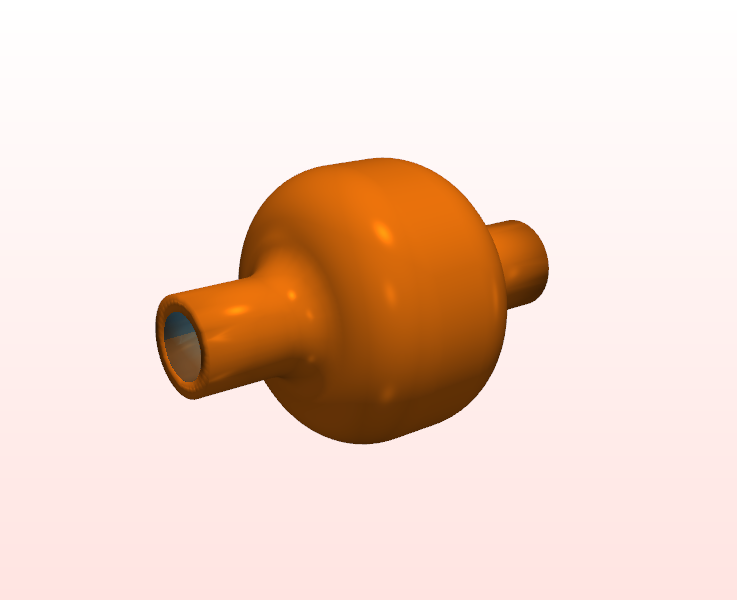 |  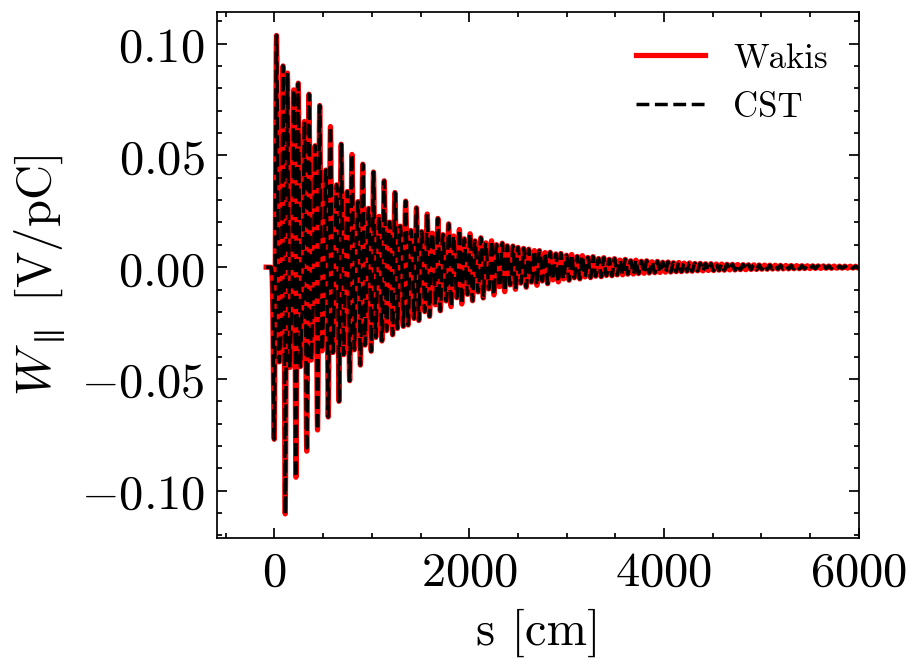  |  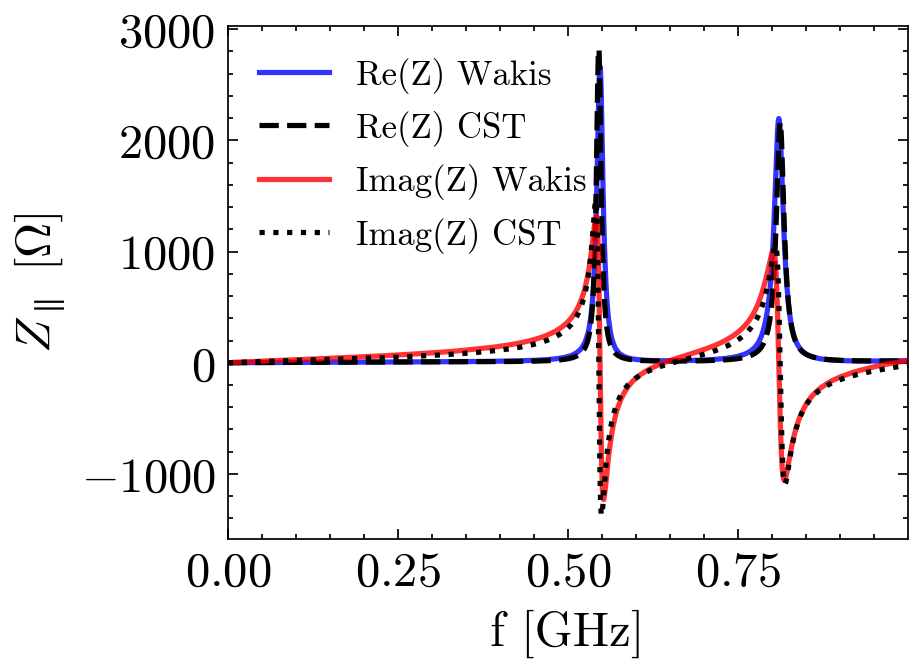   |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots 
import pyvista as pv

from wakis import SolverFIT3D
#from wakis.gridFIT3D_old import GridFIT3D
from wakis import GridFIT3D
from wakis import WakeSolver

import os 
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

#%matplotlib ipympl

'''
import nest_asyncio
nest_asyncio.apply()
from pyvista.trame.jupyter import launch_server
await launch_server().ready
#pv.set_jupyter_backend('html') 
pv.set_jupyter_backend('trame')'''

"\nimport nest_asyncio\nnest_asyncio.apply()\nfrom pyvista.trame.jupyter import launch_server\nawait launch_server().ready\n#pv.set_jupyter_backend('html') \npv.set_jupyter_backend('trame')"


### 🧱 Domain setup and grid generation

We can read the geometry, stored into `.stl` files, into python with our core dependency package `pyvista`:

And use them as input for our domain grid using `GridFIT3D`

In [2]:
stl_shell='data/001_lossymetal_shell.stl'
surf_shell= pv.read(stl_shell)
stl_cavity='data/001_vacuum_cavity.stl'
surf_cavity= pv.read(stl_cavity)
surf=surf_shell+surf_cavity


stl_solids = {"cavity": stl_cavity, "shell": stl_shell}
stl_materials = {"cavity": "vacuum", "shell": [30, 1.0, 30]}
#stl_materials = {"cavity": "vacuum", "shell": [10, 1.0, 10]}


# Generate grid
Nx = 60
Ny = 60
Nz = 140
xmin, xmax, ymin, ymax, zmin, zmax = surf.bounds

grid = GridFIT3D(
    xmin,
    xmax,
    ymin,
    ymax,
    zmin,
    zmax,
    Nx,
    Ny,
    Nz,
    stl_solids=stl_solids,
    stl_materials=stl_materials,
    stl_method='voxelize_rectilinear',
    subpixel_smoothing=True,
    subpixel_smoothing_factor=4,
    subpixel_smoothing_bool=True,
    subpixel_smoothing_threshold=0.3,
    verbose=1,
)


surf = grid.read_stl("shell")
'''vox = surf.voxelize_rectilinear(spacing=[grid_vox.dx.min(), grid_vox.dy.min(), grid_vox.dz.min()])
mask = np.reshape(vox["mask"], (Nx, Ny, Nz)).astype(bool)
grid_vox.grid['shell']=mask.ravel(order='C')'''

#rid_vox.plot_stl_mask('shell')

Generating grid with 504000 mesh cells...
Importing STL solids...
 * Marking cells inside STL solid 'cavity'...
    * STL solid cavity: 120613 cells marked inside the solid.
 * Marking cells inside STL solid 'shell'...
    * STL solid shell: 89256 cells marked inside the solid.
Total grid initialization time: 1.5955398082733154 s


'vox = surf.voxelize_rectilinear(spacing=[grid_vox.dx.min(), grid_vox.dy.min(), grid_vox.dz.min()])\nmask = np.reshape(vox["mask"], (Nx, Ny, Nz)).astype(bool)\ngrid_vox.grid[\'shell\']=mask.ravel(order=\'C\')'

In [48]:
n_inside = grid.grid.threshold(scalars='shell', value=0.5).n_cells
print(n_inside)

61258


In [50]:
voxel_size = np.min(grid.dx)*np.min(grid.dy)*np.min(grid.dz)

vol=n_inside*voxel_size
print(vol)

0.02629232100267493


In [24]:
np.round(0.038309239665264186, 10)

np.float64(0.0383092397)

In [10]:
grid.grid

StructuredGrid (0x7c6b90614ac0)
  N Cells:      504000
  N Points:     524661
  X Bounds:     -2.600e-01, 2.600e-01
  Y Bounds:     -2.600e-01, 2.600e-01
  Z Bounds:     -2.500e-01, 5.500e-01
  Dimensions:   141, 61, 61
  N Arrays:     2

### ⚡🧲 Setting up the EM Solver:

Wakis discretizes the integral form of Maxwell's equations using the Finite Integration Technique (FIT) on a structured three-dimensional Cartesian grid. To initialize the EM solver inside `SolverFIT3D` class, we need to specify the boundary conditions:

In [ ]:
#grid=GridFIT3D(load_from_h5='grids/shellgrid_enclosed_points_200x200x200.h5')

In [8]:
# boundary conditions
bc_low = ["pec", "pec", "pec"]
bc_high = ["pec", "pec", "pec"]

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

solver = SolverFIT3D(
    grid,
    # wake=None,    # can be set later
    bc_low=bc_low,
    bc_high=bc_high,
    use_stl=True,
    bg="pec",  # background material
    use_gpu=True,
    dtype=np.float32,
    #cfln=0.7,
)

Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=1.0 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 38.78701446226171 S/m
Calculating maximal stable timestep...
    * Simulation timestep: dt=6.970e-12 s
Pre-computing...
Moving to GPU...
Total solver initialization time: 0.7450113296508789 s


A few examples on how to inspect the generated fields `E`, `H`, `J`, and material tensors `sigma` (conductivity $\sigma$), `ieps` ($\varepsilon^{-1}$), `imu` ($\mu^{-1}$) 

### 🏄 Wakefield settings 

The simulation beam source and wakelength is configured inside the `WakeSolver` class, that needs to be passed to the solver `SolverFIT3D` in order to run a Wakefield simulation.

In [9]:
# ------------ Beam source ----------------
# Beam parameters
sigmaz = 10e-2  # [m] -> 2 GHz
q = 1e-9  # [C]
beta = 1.0  # beam beta
xs = 0.0  # x source position [m]
ys = 0.0  # y source position [m]
xt = 0.0  # x test position [m]
yt = 0.0  # y test position [m]
# [DEFAULT] tinj = 8.53*sigmaz/c_light  # injection time offset [s]


# ----------- Solver  setup  ----------
# Wakefield post-processor
wakelength = 10.0  # [m]
#wakelength = 40.0  # [m]
add_space = 20  # no. cells

#result_folder = 'voxelize_rectilinear/shell_cond10_wl4000'
#result_folder = 'interior_points/shell_cond10_wl4000'
#result_folder = 'interior_points/shell_cond30_wl10000'
#result_folder='voxelize_rectilinear_no_shift/shell_cond30_wl10000'
#result_folder='voxelize_rectilinear_no_shift/shell_cond10_wl4000'
#result_folder='clara_data/voxelize_rectilinear/shell_200_cond30_wl10000'
#result_folder='clara_data/implicit_distance/shell_200_cond30_wl10000'
#result_folder='clara_data/wakis070/shell_200_cond30_wl10000'
#result_folder='voxelize_rectilinear_neg_shift/shell_cond10_wl4000'
#result_folder = 'implicit_distance/shell_cond10_wl4000'
#result_folder = 'implicit_distance/shell_cond30_wl10000'
#result_folder = 'wakis070/shell_cond30_wl10000'

result_folder='/home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000'


wake = WakeSolver(
    q=q,
    sigmaz=sigmaz,
    beta=beta,
    xsource=xs,
    ysource=ys,
    xtest=xt,
    ytest=yt,
    add_space=add_space,
    results_folder=result_folder,
    Ez_file=result_folder+"Ez.h5",
)

Initializing Wakefield parameters...
Total solver initialization time: 8.535385131835938e-05 s


Before running the wakefield simultion, we can inspect the imported solids, beam and wakefield integration paths included in the simulation:

### 🕒 Wakefield simulation run

    *That's it!*

Finally, the cell bellow will run the wakefield simulation with the defined beam source and wakelength: 

In [10]:
solver.reset_fields()

In [11]:
# Once everything is set up, run the wakefield simulation
solver.wakesolve(wakelength=wakelength, wake=wake, add_space=add_space, plot=False)

Running electromagnetic time-domain simulation...


100%|██████████| 5574/5574 [00:12<00:00, 454.94it/s]


Reading h5 file /home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000Ez.h5
Size of the h5 file: 0.03 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 46755/46755 [00:13<00:00, 3345.58it/s]


Elapsed time 13.975720405578613 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 46755/46755 [00:00<00:00, 229634.27it/s]

Elapsed time 0.2042081356048584 s
Calculating longitudinal impedance Z...
[!] Using analytic charge distribution λ(s) since no data was provided
Calculating transverse impedance Zx, Zy...
Calculation terminated in 14s


### 🎨 Plotting of results

Easily access the Wakefield simulation result stored in the `WakeSolver` attributes:
* Longitudinal: s, WP, Z
* Transverse: s, WPx, WPy, Zx, Zy
* Charge distribution [C/m]: s, lambdas

<>:40: SyntaxWarning: invalid escape sequence '\O'
<>:40: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_4004129/2662482355.py:40: SyntaxWarning: invalid escape sequence '\O'
  ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="b")


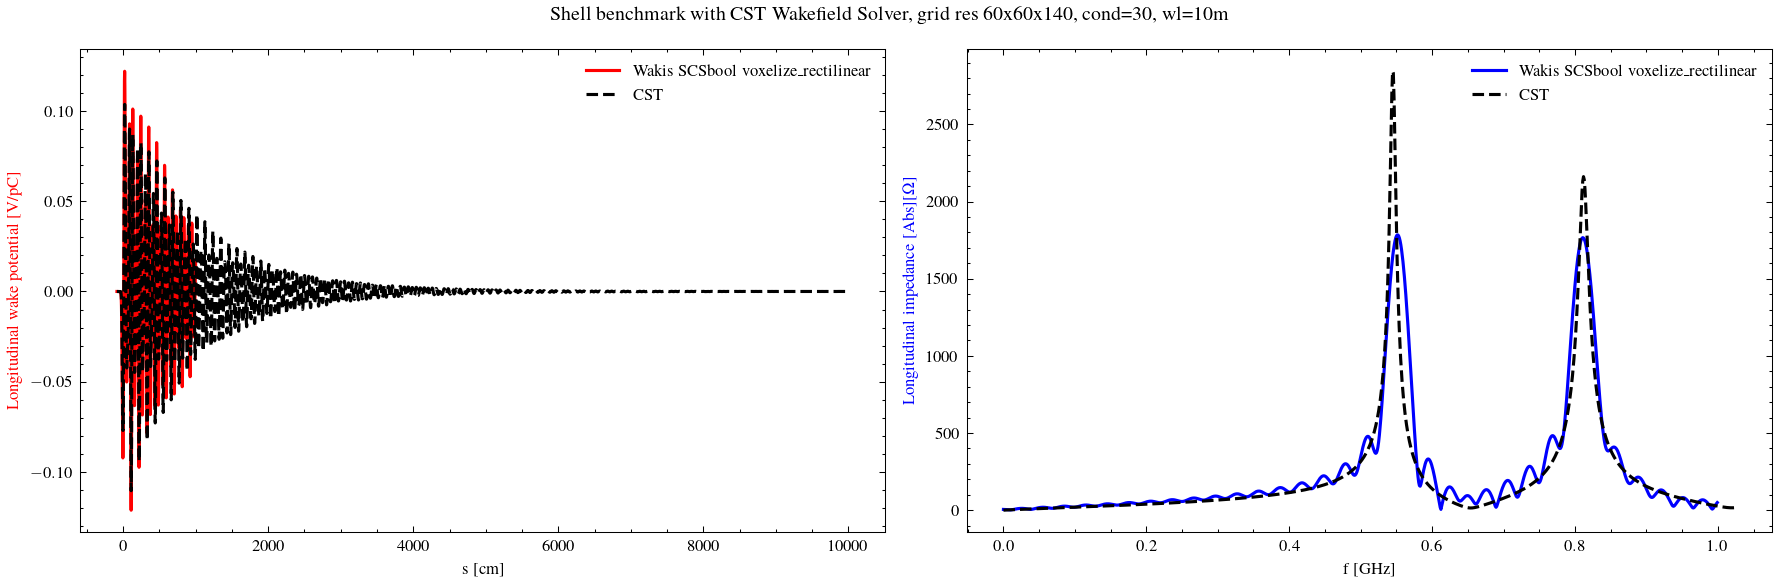

In [12]:
%matplotlib ipympl
# For scientific paper-like plots
import scienceplots
plt.style.use(['science','ieee'])

# Compare to benchmark data, if available
compare_to_CST = True


fig, ax = plt.subplots(1, 2, figsize=[12, 4], dpi=150)
#ax[0].plot(wake.s * 1e2, wake.lambdas *  wake.WP.max()/wake.lambdas.max(), c='orange', label='Beam current' )
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis v0.7.0 enclosed_points")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis Interior_points")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis Implicit_distance")

ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis SCSbool voxelize_rectilinear")

#WP=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000/WP.txt", skiprows=2,delimiter=None, usecols=None)
#ax[0].plot(WP[:,0]* 1e2, WP[:,1], c="pink", lw=1.5, label="Wakis enclosed_points legacy")

#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis voxelize_rectilinear (no shift)")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis voxelize_rectilinear")
ax[0].set_xlabel("s [cm]")
ax[0].set_ylabel("Longitudinal wake potential [V/pC]", color="r")
ax[0].legend()

#ax[1].plot(wake.f * 1e-9, np.abs(wake.lambdaf) *  np.abs(wake.Z).max()/wake.lambdaf.max(), c='grey', label='Beam Spectrum' )
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis v0.7.0 enclosed_points")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis Interior_points")

#Z=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000/Z.txt", skiprows=2, delimiter=None, usecols=None, dtype=complex)
#ax[1].plot(Z[:,0]* 1e-9, np.abs(Z[:,1]), c="cyan", lw=1.5, label="Wakis enclosed_points legacy")

#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis Implicit_distance")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis voxelize_rectilinear")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis voxelize_rectilinear (no shift)")
ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis SCSbool voxelize_rectilinear")

ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="b")
ax[1].legend()

if compare_to_CST:
    # CST wake and impedace data:
    #cstWP = wake.read_txt("/home/cwimmelm/wakis/benchmarks/CST/WP_wl10000.txt")
    #cstZ = wake.read_txt("/home/cwimmelm/wakis/benchmarks/CST/Z_wl10000.txt")

    cstWP = np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/CST/shell/WP_cond30_wl10000.txt", skiprows=2, delimiter=None, usecols=None)
    #cstWP=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/CST/shell/WP_cond10_wl4000.txt", skiprows=2,delimiter=None, usecols=None)
    
    cstZ=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/CST/shell/Z_cond30_wl10000.txt", skiprows=2,delimiter=None, usecols=None)
    #cstZ=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/CST/shell/Z_cond10_wl4000.txt", skiprows=2,delimiter=None, usecols=None)

    ax[0].plot(cstWP[:,0], cstWP[:,1], c="k", ls="--", lw=1.5, label="CST")
    ax[1].plot(cstZ[:,0], cstZ[:,1], c="k", ls="--", lw=1.5, label="CST")
    fig.suptitle("Shell benchmark with CST Wakefield Solver, grid res 60x60x140, cond=30, wl=10m")
    ax[0].legend()
    ax[1].legend()


#result_folder = 'implicit_distance/shell_cond30_wl10000'
fig.tight_layout()
#fig.savefig("001_results/benchmark.png")
#fig.savefig(f"{result_folder}/benchmark_re.png")
fig.savefig(f"{result_folder}/benchmark_shell_cond30_wl1000.png")

In [13]:
print(len(wake.WP))
print(len(wake.Z))

5195
998


In [53]:
result_folder='/home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000'


WP=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000/WP.txt", skiprows=2,delimiter=None, usecols=None)
Z=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000/Z.txt", skiprows=2, delimiter=None, usecols=None, dtype=complex)


In [61]:
WP_sliced = WP[::50, 1]

# 2. Format it cleanly as a Python array string
array_str = np.array2string(WP_sliced, separator=", ", max_line_width=100, threshold=np.inf)

#np.cumsum(np.abs(np.array({array_str})))[-1]
cumsum_val = np.cumsum(np.abs(WP[:, 1]))[-1]
print(f"Expected cumsum value: {cumsum_val}")

'''
# 3. Save it to your test file
with open(f"{result_folder}/WP_test.txt", "w") as f:
    f.write(f"self.WP = np.array({array_str})\n")'''

Expected cumsum value: 141.8402107359091


'\n# 3. Save it to your test file\nwith open(f"{result_folder}/WP_test.txt", "w") as f:\n    f.write(f"self.WP = np.array({array_str})\n")'

In [62]:
cumsum_val = np.cumsum(np.abs(Z[:, 1]))[-1]
print(f"Expected cumsum value: {cumsum_val}")

Expected cumsum value: 249395.46953432143


In [55]:
Z_sliced = Z[::20, 1]

# 2. Format it cleanly as a Python array string
array_str = np.array2string(Z_sliced, separator=", ", max_line_width=100, threshold=np.inf)

# 3. Save it to your test file
with open(f"{result_folder}/Z_test.txt", "w") as f:
    f.write(f"self.Z = np.array({array_str})\n")

In [52]:
len(Z)

1001

In [ ]:
len(WP)

In [ ]:
import h5py
import numpy as np

h5_path = '/home/cwimmelm/wakis/clara_benchmarks/Wakis/test/cavity/SCSbool0p3/shell_cond30_wl1000Ez.h5'

with h5py.File(h5_path, 'r') as h5_file:
    Ez = np.array(h5_file).flatten() 
array_str = np.array2string(Ez[:], separator=", ", threshold=np.inf)

with open(f"{result_folder}/shell_cond30_wl1000Ez_test.txt", "w") as f:
    f.write(f"Ez = np.array({array_str})")

In [14]:
grid.plot_stl_mask_slice(plane='xy', stl_solid='shell', position=0)

Widget(value='<iframe src="http://localhost:35075/index.html?ui=P_0x74b36c28f230_1&reconnect=auto" class="pyvi…

### 🎯 Extrapolation of results to fully-decayed w/ IDDEFIX

The [IDDEFIX](https://github.com/ImpedanCEI/IDDEFIX) (Impedance Determination through Differential Evolution FItting and eXtrapolation) python package will take the partially decayed wake and give back the fully decayed wake using the **Resonator formalism** and **Diferential Evolution**'s algorithms powered with `scipy` and `pymoo`

Wakefield results from previous runs can be easily loaded (longitudinal and transverse at once) using:

In [ ]:
# from wakis import WakeSolver
# wake = WakeSolver()

# Load previously saved results
wake.load_results(folder="001_results/")

To set up our differential evolution model and boost it's performance, we need to:
* Use a moderate number of samples for the impedance: 1000 to 5000. Impedance can be easily recomputed to different `fmax` and number of `samples` using `wake.calc_long_Z()`
* Compute each Resonator's parameter bounds using `wake.get_SmartBounds()`

In [ ]:
# We can recompute the impedance with less samples to increase the EA speed
wake.calc_long_Z(samples=1001, fmax=1.2e9)

In [ ]:
%%capture --no-display
# get bounds for the Differential Evolution fitting
bounds = wake.get_SmartBounds(
    freq_data=wake.f,
    impedance_data=wake.Z,
    minimum_peak_height=800,
    distance=20,
    inspect_bounds=True,
    Rs_bounds=[0.8, 10],
    Q_bounds=[0.5, 5],
    fres_bounds=[-0.01e9, +0.01e9],
)

We can initialize the DE fitting model with the obtained bounds using `wake.get_DEmodel_fitting()`. Two DE_kernels are available:
* The default `'DE'` uses `scipy`'s differential evolution under the hood
* The option `'CMAES'` faster but less reliable for some datasets, uses `pymoo`'s CMAES algorithm under the hood

In [ ]:
DE_model = wake.get_DEmodel_fitting(
    freq_data=wake.f,
    impedance_data=wake.Z,
    plane="longitudinal",
    dim="z",
    parameterBounds=bounds.parameterBounds,
    N_resonators=bounds.N_resonators,
    DE_kernel="DE",  # worth trying also 'CMAES'!
    maxiter=1e5,
    cmaes_sigma=0.01,
    popsize=150,
    tol=1e-3,
    use_minimization=True,
    minimization_margin=[0.3, 0.2, 0.01],
)

🏁 We can now plot the extrapolated **wake function**, **wake potential** or **impedance** using the fitted model:

In [ ]:
from scipy.constants import c as c_light

# Retrieve extrapolated wake, wake function and impedance for a desired wakelength
new_wakelength = 100  # [m]
sigmaz = 10e-2  # [m] -> 2 GHz
s, wake_potential = wake.get_extrapolated_wake(
    wakelength=new_wakelength, sigma=sigmaz / c_light, use_minimization=True
)
t, wake_function = wake.get_extrapolated_wake_function(
    wakelength=new_wakelength, use_minimization=True
)
f, impedance = wake.get_extrapolated_impedance(
    wakelength=new_wakelength, use_minimization=True
)

# And optionally save them as .txt ASCII files
wake.save_txt(
    f"001_results/extrapolated_wake_{int(new_wakelength)}",
    s,
    wake_potential,
    x_name="s [m]",
    y_name="Wake Potential [V/pC]",
)
wake.save_txt(
    f"001_results/extrapolated_wake_function_{int(new_wakelength)}",
    t,
    wake_function,
    x_name="t [s]",
    y_name="Wake Function [V/pC]",
)
wake.save_txt(
    f"001_results/extrapolated_impedance_{int(new_wakelength)}",
    f,
    impedance,
    x_name="f [Hz]",
    y_name="Impedance [Ohm]",
)

In [ ]:
# Plot comparison between original and extrapolated results

fig, ax = plt.subplots(2, 1, figsize=[8, 8], dpi=100)
ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis")
ax[0].plot(
    s * 1e2, wake_potential, c="r", lw=3, alpha=0.5, label="Wakis DE extrapolation"
)
# ax[0].plot(t*c_light*1e2, wake_function/c_light, c='grey', lw=1.5, alpha=0.5, label='Wakis DE extrapolation')
ax[0].set_xlabel("s [cm]")
ax[0].set_ylabel("Longitudinal wake potential [V/pC]", color="r")
ax[0].legend()

ax[1].plot(wake.f * 1e-9, np.real(wake.Z), c="b", lw=1.5, label="Wakis - Re")
ax[1].plot(wake.f * 1e-9, np.imag(wake.Z), c="b", lw=1.5, ls="--", label="Wakis - Imag")

ax[1].plot(f * 1e-9, np.real(impedance), c="b", lw=3, alpha=0.5, label="Wakis DE - Re")
ax[1].plot(
    f * 1e-9,
    np.imag(impedance),
    c="b",
    lw=3,
    ls="--",
    alpha=0.5,
    label="Wakis DE - Imag",
)
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="b")
ax[1].legend()

fig.tight_layout()

#### 🤔 But, how can I trust the model's extrapolation? 

it is important to **assess the model fitting** to ensure the validity of the extrapolation. This can be done by comparing the simulated short-range impedance and the model's fitting reconstruction:

In [ ]:
# Retrieve partially decayed wake potential
WP_pd = DE_model.get_wake_potential(
    wake.s / c_light, sigma=10e-2 / c_light, use_minimization=False
)
WP_pd_min = DE_model.get_wake_potential(
    wake.s / c_light, sigma=10e-2 / c_light, use_minimization=True
)

# Retrieve partially decayed impedance
f_pd = np.linspace(0, 1.2e9, 10000)
Z_pd = DE_model.get_impedance_from_fitFunction(f_pd, use_minimization=False)
Z_pd_min = DE_model.get_impedance_from_fitFunction(f_pd, use_minimization=True)

# Plot comparison between original and fitted results
fig1, ax = plt.subplots(1, 2, figsize=[8, 3], dpi=150)

### Wake potential comparison
ax[0].plot(
    wake.s, -WP_pd * 1e-12, c="tab:blue", alpha=0.8, lw=1.5, label="DE wake potential"
)
ax[0].plot(
    wake.s,
    -WP_pd_min * 1e-12,
    c="tab:red",
    alpha=0.6,
    lw=1.5,
    label="DE+min wake potential",
)
ax[0].plot(wake.s, wake.WP, c="k", ls="--", alpha=0.8, label="Wakis wl=30 m")
ax[0].set_xlabel("s [cm]")
ax[0].set_ylabel("Longitudinal wake potential [V/pC]", color="tab:red")
ax[0].legend()

### Impedance comparison
ax[1].plot(
    f_pd * 1e-9, np.real(Z_pd), ls="-", c="tab:blue", alpha=0.8, lw=1.5, label="DE Real"
)
# ax[1].plot(f_pd*1e-9, np.imag(Z_pd), ls=':', c='tab:blue', alpha=0.6, lw=1.5, label='DE Imag')
# ax[1].plot(f_pd*1e-9, np.abs(Z_pd), ls=':', c='tab:blue', alpha=0.6, lw=1.5, label='DE Imag')
ax[1].plot(
    f_pd * 1e-9,
    np.real(Z_pd_min),
    ls="-",
    c="tab:red",
    alpha=0.6,
    lw=1.5,
    label="DE+min Real",
)
ax[1].plot(wake.f * 1e-9, np.real(wake.Z), ls="--", c="k", lw=1.5, label="Real")
# ax[1].plot(f*1e-9, np.imag(Z), ls=':', c='k', lw=1.5, label='Imag')
# ax[1].plot(f*1e-9, np.abs(Z_pd), c='tab:blue', label='Abs')
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="tab:blue")
ax[1].legend()

fig1.tight_layout()

---------------
## 🧩 Extra: Running particular cases

Bellow, some other ways of running a Wakefield simulation are included, in order to showcase the flexibility and capabilities of our solver:


#### Running and 3d plotting $E_{Abs}$ on-the-fly with `solver.one_step()`
This cell shows how to run Wakis with custom time-loops, calling the time field update with through the `one_step()` method.

In [ ]:
import os
from wakis.sources import Beam
from tqdm import tqdm

# ------------ Beam source ----------------
# Beam parameters
sigmaz = 10e-2  # [m] -> 2 GHz
q = 1e-9  # [C]
beta = 1.0  # beam beta
xs = 0.0  # x source position [m]
ys = 0.0  # y source position [m]
xt = 0.0  # x test position [m]
yt = 0.0  # y test position [m]
# [DEFAULT] tinj = 8.53*sigmaz/c_light  # injection time offset [s]

beam = Beam(q=q, sigmaz=sigmaz, beta=beta, xsource=xs, ysource=ys)

if not os.path.exists("001_img/"):
    os.makedirs("001_img/")

Nt = 3000
for n in tqdm(range(Nt)):
    beam.update(solver, n * solver.dt)

    if n % 50 == 0 and n > 600:
        solver.plot3DonSTL(
            "E",
            component="Abs",
            cmap="rainbow",
            clim=[0, 500],
            stl_with_field="cavity",
            field_opacity=1.0,
            stl_transparent="shell",
            stl_opacity=0.1,
            stl_colors="white",
            clip_plane=True,
            clip_normal="-y",
            clip_origin=[0, 0, 0],
            off_screen=True,
            zoom=1.2,
            n=n,
            title="001_img/EzonSTL",
        )

    solver.one_step()

In [ ]:
!convert -delay 10 -loop 0 001_img/EzonSTL_*.png 001_img/EzonSTL_simulation.gif

![Generated Ez field animation interpolated on the vacuum region](001_img/EzonSTL_simulation.gif)

#### Running with `solver.emsolve()` to calculate only EM fields
This solver routine does not compute the wake potential and the impedance and it is recommended for EM fields plotting and diagnostics

With on-the-fly 2d plotting

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "name", plt.cm.jet(np.linspace(0.1, 0.9))
)  # CST's colormap

plotkw2D = {
    "title": "001_img/Ez",
    "add_patch": ["cavity"],
    "patch_alpha": 1.0,
    "patch_reverse": True,
    "vmin": -1e3,
    "vmax": 1e3,
    "cmap": cmap,
    "plane": [int(Nx / 2), slice(0, Ny), slice(add_space, -add_space)],
}


from wakis.sources import Beam

beam = Beam(q=q, sigmaz=sigmaz, beta=beta, xsource=xs, ysource=ys)

solver.emsolve(Nt=3000, source=beam, plot=True, plot_every=50, **plotkw2D)

In [ ]:
!convert -delay 10 -loop 0 001_img/Ez_*.png 001_img/Ez_simulation.gif

![Generated Ez field animation](001_img/Ez_simulation.gif)

Or on-the-fly 3d plotting

In [ ]:
plotkw3D = {
    "title": "001_img/Ez3d",
    "add_stl": "shell",
    "stl_opacity": 0.1,
    "clim": [-1e3, 1e3],
}

from wakis.sources import Beam

beam = Beam(q=q, sigmaz=sigmaz, beta=beta, xsource=xs, ysource=ys)

solver.emsolve(Nt=4000, source=beam, plot3d=True, plot_every=50, **plotkw3D)

In [ ]:
! convert -delay 10 -loop 0 001_img/Ez3d*.png 001_img/Ez3d_simulation.gif

![Generated Ez field animation in 3D](001_img/Ez3d_simulation.gif )

## Extra: 🌡️ computing the beam-induced heating with BIHC

Let's imagine our BE cavity is installed in the LHC and we need to estimate if the **power loss** due to impedance is high enough that it can melt or damage the component

First we define the beam filling scheme and build our beam:

In [ ]:
import bihc

In [ ]:
# Create beam object
from bihc.fillingschemes import fillingSchemeLHC

fillingScheme = fillingSchemeLHC(ninj=9, ntrains=4, nbunches=72)
bl = 1.2e-9  # bunch length [s]
Np = 2.3e11  # bunch intensity [protons/bunch]
bunchShape = "q-GAUSSIAN"  # bunch profile shape in time
qvalue = 3 / 5  # value of q parameter in the q-gaussian distribution
fillMode = "FLATTOP"  # Energy
fmax = 2e9  # Maximum frequency of the beam spectrum [Hz]

beam = bihc.Beam(
    Np=Np,
    bunchLength=bl,
    fillingScheme=fillingScheme,
    bunchShape=bunchShape,
    qvalue=qvalue,
    machine="LHC",
    fillMode=fillMode,
    spectrum="numeric",
    fmax=fmax,
)

print(f"* Number of bunches used: {np.sum(fillingScheme)}")
print(f"* Total intensity: {np.sum(fillingScheme) * Np:.2e} protons")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=[14, 6])

t, prof = beam.longitudinalProfile
ax[0].plot(
    t * 1e6,
    prof * beam.Np,
)
ax[0].set_xlabel("Time [ms]")
ax[0].set_ylabel("Profile Intensity [protons]")

f, spectrum = beam.spectrum
ax[1].plot(f * 1e-9, spectrum * beam.Np * np.sum(fillingScheme), c="r")
ax[1].set_xlabel("Frequency [GHz]")
ax[1].set_ylabel("Spectrum Intensity [protons]")
ax[1].set_xlim((0, 2.0))

### Impedance and spectrum
The beam induced heating depends on the interaction of the beam power spectrum and the beam-coupling impedance:

$$
P_{loss} = 2 (f_0 eN_{beam})^2 \cdot \sum_{p=0}^{+\infty} |\Lambda(p\omega_0)|^2 Re[Z_z(p \omega_0)]
$$

To assess it visually we can plot them together:

In [ ]:
# We create an impedance object with BIHC:

# Partially decayed impedance from simulation
# wake = WakeSolver(results_folder='001_results_wl30/')
# wake.load_results()

# Or fully decayed impedance from our extrapolation DE model
# f, impedance = wake.get_extrapolated_impedance(wakelength=new_wakelength, use_minimization=True)

f, impedance = wake.read_txt("results_001/extrapolated_impedance_100.txt").values()
Z = bihc.Impedance(f=f.real, Z=impedance)

In [ ]:
# Plot impedance and spectrum
fig, ax = plt.subplots(figsize=[10, 5])
axx = ax.twinx()

(l0,) = ax.plot(
    beam.powerSpectrum[0] / 1e9, beam.powerSpectrum[1], color="r", alpha=0.7
)
(l1,) = axx.plot(Z.f / 1e9, Z.Zr, color="k", alpha=0.8, ls="-")

ax.set_ylabel("Power spectrum amplitude [a.u.]", color="k")
# ax.set_yscale('log')
ax.set_xlabel("Frequency [GHz]")
ax.set_xlim((0, 1.5))
ax.set_ylim(ymin=0, ymax=1.1)

axx.set_ylabel(r"Longitudinal Impedance Re(Z) [$\Omega$]", color="k")
axx.set_ylim(ymin=1e-0)
# axx.set_yscale('log')

axx.legend([l0, l1], ["$\Lambda^2$ Power spectrum", "Re(Z) BE cavity impedance"], loc=0)

fig.tight_layout()

### Calculate Beam-Induced power loss
With `BIHC` we can simply calculate the power loss by `beam.getPloss(Z)`. 

However, due to inacuracies in the wakefield simulation or the CAD model, or to account for changes in the revolution frequency during operation, `BIHC` also performs a **statistical analysis** by rigidly shifting the impedance curve `beam.getShiftedPloss(Z, shift=shift)` to account for different overlaps with the beam spectral lines:

In [ ]:
print("Calculate beam-induced heating of CAP-cavity impedance")
print("----------------------------------------------------")
# Get unshifted ploss
ploss, ploss_density = beam.getPloss(Z)
print(f"Dissipated power (no-shift): {ploss:.3} W")

# Get min/max power loss with rigid shift
shift = 20e6  # distance between shift steps [Hz]
shifts, power = beam.getShiftedPloss(Z, shift=shift)

print(
    f"Minimum dissipated power: P_min = {np.min(power):.3} W, at step {shifts[np.argmin(power)]}"
)
print(
    f"Maximum dissipated power: P_max = {np.max(power):.3} W, at step {shifts[np.argmax(power)]}"
)
print(f"Average dissipated power: P_mean = {np.mean(power):.3} W")

We can now retrieve and plot the impedance curve that gives the maximum power loss. We can observe that when the peak at lower frequency is shifted and placed exactly on top of the beam spectral line, the power loss dramatically increases


In [ ]:
# Get unshifted ploss max
Z_max = beam.Zmax

# Plot impedance and spectrum
fig, ax = plt.subplots(figsize=[10, 5])
axx = ax.twinx()

(l0,) = ax.plot(
    beam.powerSpectrum[0] / 1e9, beam.powerSpectrum[1], color="r", alpha=0.7
)
(l1,) = axx.plot(Z.f / 1e9, Z.Zr, color="k", alpha=0.8, ls="-")
(l2,) = axx.plot(Z_max.f / 1e9, Z_max.Zr, color="b", alpha=0.8, ls="-")

ax.set_ylabel("Power spectrum amplitude [a.u.]", color="k")
ax.set_xlabel("Frequency [GHz]")
ax.set_xlim((0, 1.5))
# ax.set_ylim(ymin=1e-3, ymax=1.1)
# ax.set_yscale('log')

axx.set_ylabel(r"Longitudinal Impedance Re(Z) [$\Omega$]", color="k")
# axx.set_ylim(ymin=1e-1, ymax=1e5)
# axx.set_yscale('log')

axx.legend(
    [l0, l1, l2],
    [
        "$\Lambda^2$ Power spectrum",
        "Re(Z) BE cavity impedance",
        "Re(Z) Shifted BE cavity impedance",
    ],
    loc=0,
)

fig.tight_layout()

We can also plot the power loss by frequency with the power loss density:

In [ ]:
fig, ax = plt.subplots(figsize=[10, 7])

# Unshifted impedance
ploss, ploss_density = beam.getPloss(Z)
# Shifted impedance
ploss_max, ploss_density_max = beam.getPloss(Z_max)

(l1,) = ax.plot(
    np.linspace(0, Z_max.f.max() / 1e9, len(ploss_density_max)),
    ploss_density_max,
    color="r",
    marker="v",
    lw=3,
    alpha=0.8,
)
(l0,) = ax.plot(
    np.linspace(0, Z.f.max() / 1e9, len(ploss_density)),
    ploss_density,
    color="k",
    marker="v",
    lw=3,
    alpha=0.8,
)

ax.set_ylabel("Power by frequency [W]", color="k")
ax.set_yscale("log")
ax.set_xlabel("Frequency [GHz]")
ax.set_xlim((0, 1.5))
ax.set_ylim(ymin=1e-1, ymax=1e5)
ax.grid(which="minor", axis="y", alpha=0.8, ls=":")

ax.legend([l0, l1, l2], ["Ploss", "Ploss Max."], loc=1, fontsize=14)
ax.text(
    0.5,
    0.9,
    f"Ploss avg = {round(np.mean(power), 2)} W \n Ploss max. = {round(np.max(power), 2)} W",
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax.transAxes,
    bbox={"facecolor": "white", "alpha": 0.6, "pad": 10},
    color="k",
    fontsize=14,
)

fig.suptitle("Power loss by frequency")
fig.tight_layout()